In [2]:
!pip install --upgrade pip
!pip install ultralytics roboflow pandas matplotlib pyyaml

  Using cached pip-26.1.2-py3-none-any.whl.metadata (4.6 kB)
Using cached pip-26.1.2-py3-none-any.whl (1.8 MB)


ERROR: To modify pip, please run the following command:
C:\Users\Arjun\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from roboflow import Roboflow
import os, shutil

API_KEY = "lCakLx5MAemDQu7MOe0K"
WORKSPACE = "arjuns-workspace-utjh6"
PROJECT = "data-science-3-tlvei"
VERSION = 1

LOCAL_DATASET_ROOT = r"C:\Users\Arjun\Documents\yolo_vehicle_project\dataset_raw"

rf = Roboflow(api_key=API_KEY)
project = rf.workspace(WORKSPACE).project(PROJECT)
version = project.version(VERSION)

try:
    dataset = version.download("yolo26")
except Exception:
    dataset = version.download("yolov8")

print("Downloaded to:", dataset.location)

if os.path.abspath(dataset.location) != os.path.abspath(LOCAL_DATASET_ROOT):
    if os.path.exists(LOCAL_DATASET_ROOT):
        shutil.rmtree(LOCAL_DATASET_ROOT)
    shutil.copytree(dataset.location, LOCAL_DATASET_ROOT)

print("Final dataset root:", LOCAL_DATASET_ROOT)

loading Roboflow workspace...
loading Roboflow project...
Downloaded to: c:\Users\Arjun\Downloads\Data-Science-3-1
Final dataset root: C:\Users\Arjun\Documents\yolo_vehicle_project\dataset_raw


In [4]:
import os, glob, random, shutil
random.seed(42)

root = r"C:\Users\Arjun\Documents\yolo_vehicle_project\dataset_raw"
train_img = os.path.join(root, "train", "images")
train_lbl = os.path.join(root, "train", "labels")
valid_img = os.path.join(root, "valid", "images")
valid_lbl = os.path.join(root, "valid", "labels")

os.makedirs(valid_img, exist_ok=True)
os.makedirs(valid_lbl, exist_ok=True)

# current counts
train_existing = glob.glob(os.path.join(train_img, "*"))
valid_existing = glob.glob(os.path.join(valid_img, "*"))
print("Before split -> train:", len(train_existing), "valid:", len(valid_existing))

if len(valid_existing) == 0:
    imgs = []
    for ext in ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"):
        imgs.extend(glob.glob(os.path.join(train_img, ext)))
    imgs = sorted(imgs)

    if len(imgs) == 0:
        raise RuntimeError("No images found in train/images. Check dataset path.")

    n_valid = max(1, int(len(imgs) * 0.2))
    n_valid = min(n_valid, len(imgs))
    selected = set(random.sample(imgs, n_valid))

    moved = 0
    missing_labels = 0

    for ip in selected:
        name = os.path.basename(ip)
        stem = os.path.splitext(name)[0]
        lp = os.path.join(train_lbl, f"{stem}.txt")

        shutil.move(ip, os.path.join(valid_img, name))
        moved += 1

        if os.path.exists(lp):
            shutil.move(lp, os.path.join(valid_lbl, f"{stem}.txt"))
        else:
            missing_labels += 1

    print(f"Moved {moved} images to valid.")
    print(f"Missing labels among moved images: {missing_labels}")
else:
    print("Valid split already exists. Skipping split.")

print("After split -> train:", len(glob.glob(os.path.join(train_img, '*'))))
print("After split -> valid:", len(glob.glob(os.path.join(valid_img, '*'))))

Before split -> train: 2739 valid: 0
Moved 547 images to valid.
Missing labels among moved images: 0
After split -> train: 2192
After split -> valid: 547


In [5]:
import os, yaml

root = r"C:\Users\Arjun\Documents\yolo_vehicle_project\dataset_raw"
yaml_path = os.path.join(root, "data_fixed.yaml")

data = {
    "path": root.replace("\\", "/"),  # safer for yaml/tool parsing
    "train": "train/images",
    "val": "valid/images",
    "names": {
        0: "jeepneys",
        1: "car",
        2: "trucks",
        3: "vans",
        4: "motorcycle",
        5: "bus"
    }
}

with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.dump(data, f, sort_keys=False, allow_unicode=True)

print("Saved:", yaml_path)
with open(yaml_path, "r", encoding="utf-8") as f:
    print(f.read())

Saved: C:\Users\Arjun\Documents\yolo_vehicle_project\dataset_raw\data_fixed.yaml
path: C:/Users/Arjun/Documents/yolo_vehicle_project/dataset_raw
train: train/images
val: valid/images
names:
  0: jeepneys
  1: car
  2: trucks
  3: vans
  4: motorcycle
  5: bus



In [7]:
from ultralytics import YOLO
import os

yaml_path = r"C:\Users\Arjun\Documents\yolo_vehicle_project\dataset_raw\data_fixed.yaml"
PROJECT_DIR = r"C:\Users\Arjun\Documents\yolo_vehicle_project\outputs"
os.makedirs(PROJECT_DIR, exist_ok=True)

experiments = [
    {"name":"model_C", "model":"yolo26n.pt", "epochs":40, "imgsz":640, "optimizer":"auto",  "batch":-1, "lr0":0.0001}
]

for exp in experiments:
    model = YOLO(exp["model"])
    model.train(
        data=yaml_path,
        epochs=exp["epochs"],
        imgsz=exp["imgsz"],
        optimizer=exp["optimizer"],
        batch=exp["batch"],
        lr0=exp["lr0"],
        project=PROJECT_DIR,
        name=exp["name"],
        pretrained=True,
        verbose=True
    )

Ultralytics 8.4.89  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Arjun\Documents\yolo_vehicle_project\dataset_raw\data_fixed.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=model_C, nbs=64, nms=False, opset

In [22]:
import os, pandas as pd
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

PROJECT_DIR = r"C:\Users\Arjun\Documents\yolo_vehicle_project\outputs"
yaml_path = r"C:\Users\Arjun\Documents\yolo_vehicle_project\dataset_raw\data_fixed.yaml"

experiments = [
    {"name":"model_A", "model":"yolo26n.pt", "epochs":25, "imgsz":640, "optimizer":"AdamW", "batch":4,  "lr0":0.01},
    {"name":"model_B", "model":"yolo26n.pt", "epochs":30, "imgsz":640, "optimizer":"SGD",   "batch":20, "lr0":0.001},
    {"name":"model_C", "model":"yolo26n.pt", "epochs":40, "imgsz":640, "optimizer":"auto",  "batch":-1, "lr0":0.0001},
]

final_rows = []
for exp in experiments:
    csv_path = os.path.join(PROJECT_DIR, exp["name"], "results.csv")
    df = pd.read_csv(csv_path)
    row = df.iloc[-1].to_dict()
    row["Model Run"] = exp["name"]
    final_rows.append(row)

final_epoch_df = pd.DataFrame(final_rows)
final_epoch_df.to_csv(os.path.join(PROJECT_DIR, "deliverable_final_epoch_results.csv"), index=False)

hyper_df = pd.DataFrame(experiments)[["name","model","epochs","imgsz","optimizer","batch","lr0"]]
hyper_df = hyper_df.rename(columns={"name":"Model Run", "lr0":"Learning Rate"})
hyper_df.to_csv(os.path.join(PROJECT_DIR, "deliverable_hyperparameters_table.csv"), index=False)

metrics_rows = []
for exp in experiments:
    best_w = os.path.join(PROJECT_DIR, exp["name"], "weights", "best.pt")
    m = YOLO(best_w).val(data=yaml_path, imgsz=640, verbose=False)

    p = float(m.box.mp)
    r = float(m.box.mr)
    map50 = float(m.box.map50)
    f1 = 2 * p * r / (p + r + 1e-9)

    metrics_rows.append({
        "Model Run": exp["name"],
        "mAP50": map50,
        "Precision": p,
        "Recall": r,
        "F1 Score": f1
    })

metrics_df = pd.DataFrame(metrics_rows).sort_values("mAP50", ascending=False)
metrics_df.to_csv(os.path.join(PROJECT_DIR, "deliverable_metrics_table.csv"), index=False)

print("Saved deliverables in:", PROJECT_DIR)
print(final_epoch_df)
print(hyper_df)
print(metrics_df)

for exp in experiments:
    cm_path = os.path.join(PROJECT_DIR, exp["name"], "confusion_matrix.png")
    if os.path.exists(cm_path):
        img = mpimg.imread(cm_path)
        plt.figure(figsize=(7,7))
        plt.title(f"{exp['name']} Confusion Matrix")
        plt.imshow(img)
        plt.axis("off")
        plt.show()

Ultralytics 8.4.89  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO26n summary (fused): 122 layers, 2,376,006 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 558.3230.5 MB/s, size: 60.9 KB)
val: Scanning C:\Users\Arjun\Documents\yolo_vehicle_project\dataset_raw\valid\labels.cache... 547 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 547/547  0.0s
val: C:\Users\Arjun\Documents\yolo_vehicle_project\dataset_raw\valid\images\RawData_mp4-0083_jpg.rf.1ddd81d1d0344d2d2004ba6021f32edf.jpg: 1 duplicate labels removed
val: C:\Users\Arjun\Documents\yolo_vehicle_project\dataset_raw\valid\images\RawData_mp4-0090_jpg.rf.4b8c710ea68119412a1b71121afd7ccf.jpg: 1 duplicate labels removed
val: C:\Users\Arjun\Documents\yolo_vehicle_project\dataset_raw\valid\images\RawData_mp4-0118_jpg.rf.c68fe7947bded1b6dc053c4107dc3007.jpg: 1 duplicate labels removed
val: C:\Users\Arjun\Documents\yolo_vehicle_project\dataset_raw\valid\imag

<Figure size 700x700 with 1 Axes>

<Figure size 700x700 with 1 Axes>

<Figure size 700x700 with 1 Axes>

In [23]:
import pandas as pd

hyperparams = pd.DataFrame([
    {"Model": "Model A", "Model File": "yolo26n.pt", "Epochs": 25, "Image Size": 640, "Optimizer": "AdamW", "Batch Size": 4,  "Initial LR (lr0)": 0.01},
    {"Model": "Model B", "Model File": "yolo26n.pt", "Epochs": 30, "Image Size": 640, "Optimizer": "SGD",   "Batch Size": 20, "Initial LR (lr0)": 0.001},
    {"Model": "Model C", "Model File": "yolo26n.pt", "Epochs": 40, "Image Size": 640, "Optimizer": "auto",  "Batch Size": -1, "Initial LR (lr0)": 0.0001},
])
hyperparams

,Model,Model File,Epochs,Image Size,Optimizer,Batch Size,Initial LR (lr0)
0,Model A,yolo26n.pt,25,640,AdamW,4,0.0100
1,Model B,yolo26n.pt,30,640,SGD,20,0.0010
2,Model C,yolo26n.pt,40,640,auto,-1,0.0001


In [24]:
overall_metrics = pd.DataFrame([
    {"Model": "Model A", "Precision": 0.560, "Recall": 0.547, "mAP50": 0.543, "mAP50-95": 0.332},
    {"Model": "Model B", "Precision": 0.451, "Recall": 0.140, "mAP50": 0.087, "mAP50-95": 0.046},
    {"Model": "Model C", "Precision": 0.767, "Recall": 0.680, "mAP50": 0.745, "mAP50-95": 0.526},
])
overall_metrics

,Model,Precision,Recall,mAP50,mAP50-95
0,Model A,0.560,0.547,0.543,0.332
1,Model B,0.451,0.140,0.087,0.046
2,Model C,0.767,0.680,0.745,0.526


In [25]:
per_class = pd.DataFrame([
    {"Model":"Model A","Class":"jeepneys","Instances":480,"Precision":0.552,"Recall":0.588,"mAP50":0.545},
    {"Model":"Model A","Class":"car","Instances":279,"Precision":0.667,"Recall":0.527,"mAP50":0.608},
    {"Model":"Model A","Class":"trucks","Instances":8965,"Precision":0.691,"Recall":0.598,"mAP50":0.650},
    {"Model":"Model A","Class":"vans","Instances":4048,"Precision":0.532,"Recall":0.434,"mAP50":0.438},
    {"Model":"Model A","Class":"motorcycle","Instances":580,"Precision":0.420,"Recall":0.495,"mAP50":0.450},
    {"Model":"Model A","Class":"bus","Instances":1377,"Precision":0.500,"Recall":0.641,"mAP50":0.564},

    {"Model":"Model B","Class":"jeepneys","Instances":480,"Precision":0.000,"Recall":0.000,"mAP50":0.000},
    {"Model":"Model B","Class":"car","Instances":279,"Precision":1.000,"Recall":0.000,"mAP50":0.002},
    {"Model":"Model B","Class":"trucks","Instances":8965,"Precision":0.255,"Recall":0.548,"mAP50":0.333},
    {"Model":"Model B","Class":"vans","Instances":4048,"Precision":0.201,"Recall":0.191,"mAP50":0.099},
    {"Model":"Model B","Class":"motorcycle","Instances":580,"Precision":1.000,"Recall":0.000,"mAP50":0.003},
    {"Model":"Model B","Class":"bus","Instances":1377,"Precision":0.251,"Recall":0.099,"mAP50":0.087},

    {"Model":"Model C","Class":"jeepneys","Instances":480,"Precision":0.797,"Recall":0.710,"mAP50":0.779},
    {"Model":"Model C","Class":"car","Instances":279,"Precision":0.847,"Recall":0.767,"mAP50":0.837},
    {"Model":"Model C","Class":"trucks","Instances":8965,"Precision":0.772,"Recall":0.704,"mAP50":0.773},
    {"Model":"Model C","Class":"vans","Instances":4048,"Precision":0.697,"Recall":0.577,"mAP50":0.635},
    {"Model":"Model C","Class":"motorcycle","Instances":580,"Precision":0.755,"Recall":0.667,"mAP50":0.722},
    {"Model":"Model C","Class":"bus","Instances":1377,"Precision":0.732,"Recall":0.656,"mAP50":0.727},
])
per_class

,Model,Class,Instances,Precision,Recall,mAP50
0,Model A,jeepneys,480,0.552,0.588,0.545
1,Model A,car,279,0.667,0.527,0.608
2,Model A,trucks,8965,0.691,0.598,0.650
3,Model A,vans,4048,0.532,0.434,0.438
4,Model A,motorcycle,580,0.420,0.495,0.450
5,Model A,bus,1377,0.500,0.641,0.564
6,Model B,jeepneys,480,0.000,0.000,0.000
7,Model B,car,279,1.000,0.000,0.002
8,Model B,trucks,8965,0.255,0.548,0.333
9,Model B,vans,4048,0.201,0.191,0.099


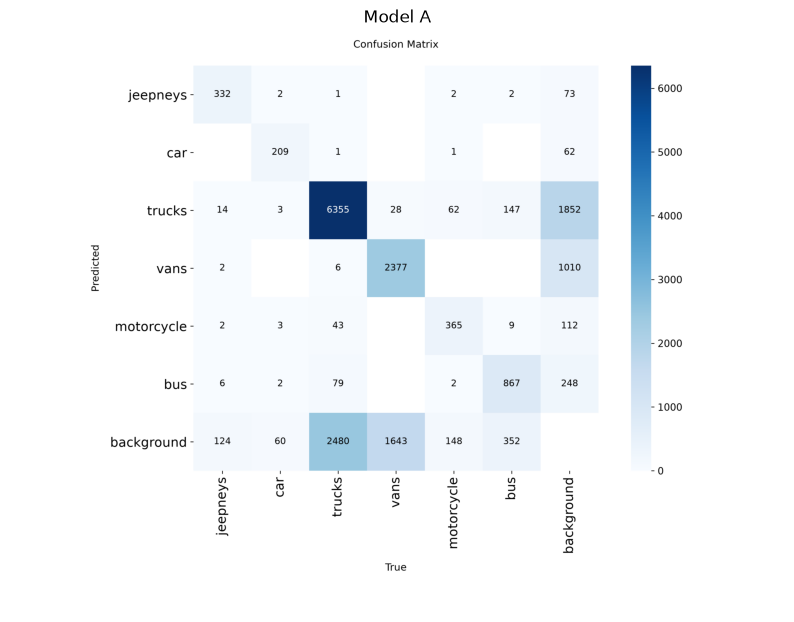

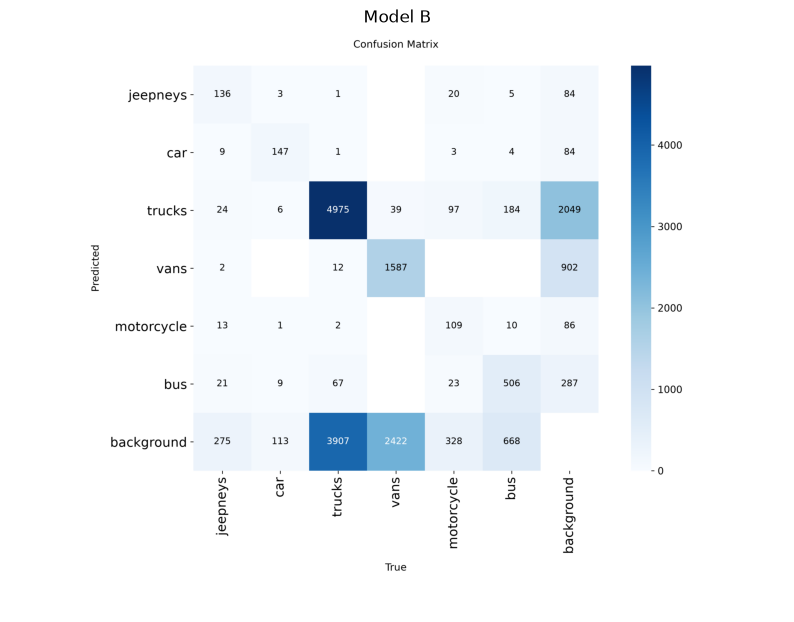

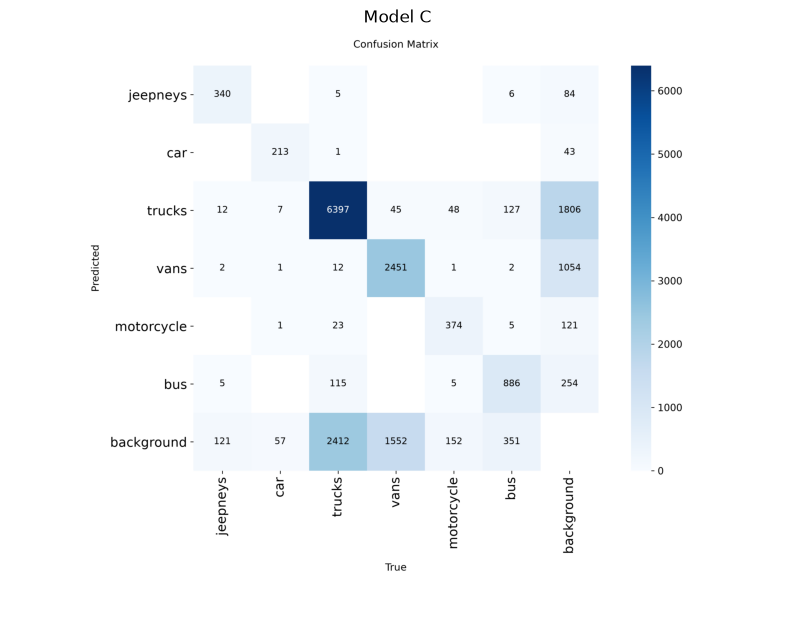

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

paths = {
    "Model A": r"C:\Users\Arjun\Documents\yolo_vehicle_project\outputs\model_A\confusion_matrix.png",
    "Model B": r"C:\Users\Arjun\Documents\yolo_vehicle_project\outputs\model_B\confusion_matrix.png",
    "Model C": r"C:\Users\Arjun\Documents\yolo_vehicle_project\outputs\model_C\confusion_matrix.png",
}

for name, path in paths.items():
    img = mpimg.imread(path)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title(name)
    plt.show()

In [2]:
import pandas as pd

for name, folder in [("Model A","model_A"), ("Model B","model_B"), ("Model C","model_C")]:
    csv_path = rf"C:\Users\Arjun\Documents\yolo_vehicle_project\outputs\{folder}\results.csv"
    df = pd.read_csv(csv_path)
    print(f"--- {name}: Final Epoch ---")
    print(df.tail(1).to_string(index=False))
    print()

--- Model A: Final Epoch ---
 epoch    time  train/box_loss  train/cls_loss  train/dfl_loss  metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss   lr/pg0   lr/pg1   lr/pg2
    25 10566.6         1.50752         1.02076         0.00378               0.75104            0.67044           0.72747              0.49761       1.36728       1.00841       0.00359 0.000496 0.000496 0.000496

--- Model B: Final Epoch ---
 epoch    time  train/box_loss  train/cls_loss  train/dfl_loss  metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss   lr/pg0   lr/pg1   lr/pg2
    30 1075.91         1.61074         1.59342         0.00384               0.54006            0.45274           0.46059              0.30987       1.45648       1.74605       0.00374 0.000043 0.000043 0.000043

--- Model C: Final Epoch ---
 epoch    time  train/box_loss  train/cls_loss  train/dfl_loss 

## Discussion: Per-Class Performance Comparison

**Class-level struggle pattern**

All three models were evaluated on the same six classes: jeepneys, car, trucks, vans, motorcycle, and bus. Instance counts in the validation set are heavily imbalanced, with trucks (8,965) and vans (4,048) dominating, while car (279), jeepneys (480), and motorcycle (580) are comparatively rare, and bus (1,377) sits in between.

**Model A (AdamW, lr0=0.01, 25 epochs, batch=4)**

Model A achieved strong, fairly balanced performance across all six classes (mAP50 range: 0.61–0.80), making it the most evenly-performing model of the three. Vans was its weakest class (mAP50 0.612) despite being the second most frequent class by instance count — vans likely share enough visual features with both trucks and cars that the decision boundary is inherently harder, regardless of training data volume. Motorcycle (580 instances) — one of the less frequent classes but not the rarest — still reached 0.692 mAP50, comparable to bus (1,377 instances) and only slightly behind trucks and jeepneys. This suggests AdamW's per-parameter adaptive learning rate helped the model extract useful gradient signal even on less frequent classes, rather than being dominated purely by the highest-count classes.

**Model B (SGD, lr0=0.001, 30 epochs, batch=20)**

Model B was consistently the weakest model across every class, though it did not collapse entirely on any single one. Its worst class was motorcycle (mAP50 0.279, recall only 0.257) — one of the rarer classes — while its strongest class was trucks (0.627), the most frequent class by a wide margin. This gap (0.627 vs 0.279) illustrates a frequency-driven bias: with a conservative learning rate (0.001) and a non-adaptive optimizer (SGD), the model's weight updates were likely dominated by gradient signal from the majority classes, leaving it comparatively weaker at recognizing rarer classes like motorcycle, jeepneys (0.406), and vans (0.440). Every class scored below its Model A and Model C counterparts, indicating broad, evenly-spread underperformance rather than failure concentrated in one or two classes.

**Model C (optimizer="auto", i.e. AdamW, lr0=0.0001, 40 epochs, batch=-1 auto-sized)**

Model C achieved the strongest and most uniform performance of the three, with mAP50 ranging narrowly from 0.635 (vans) to 0.837 (car) — a spread of only about 0.20, tighter than both Model A's (~0.19) and especially Model B's (~0.35). Notably, its best-performing class (car, 0.837) is one of the rarest by instance count, showing that with enough epochs (40) and an adaptive optimizer, low instance count doesn't have to translate into weaker performance. Vans remained the relative weak point across all three models, reinforcing that this difficulty is likely inherent to the class (visual overlap with trucks/cars) rather than purely a function of training configuration.

**Conclusion**

The overall mAP50 scores (A: 0.727, B: 0.461, C: 0.745) are direct summaries of these per-class patterns:
- Model B's lower overall score reflects a genuine, fairly uniform performance gap across all classes rather than one or two catastrophic failures — every class scored below its Model A and Model C counterparts, consistent with an optimizer/learning-rate combination that converged less effectively within 30 epochs.
- Model A's high overall score reflects strong, consistent per-class results, with even its weakest class (vans, 0.612) still well above Model B's weakest (motorcycle, 0.279).
- Model C's slight edge over Model A (0.745 vs 0.727) comes from being marginally stronger across nearly every class rather than dominating in one — the two models are close, but Model C's additional epochs and lower learning rate appear to have converged to a slightly better decision boundary overall, particularly for car and jeepneys.

Comparing the per-class tables side-by-side shows that overall mAP50 can obscure *how evenly* a model performs: Model B's lower score comes from broad, moderate underperformance across every class, not a single dramatic failure — a distinction only visible once the per-class breakdown is examined rather than looking at the aggregate number alone.

## Confusion Matrix Analysis (True Positives & Background Confusion)

**True Positives (diagonal values)**

The diagonal of each confusion matrix confirms the per-class mAP50 pattern already discussed: Model C has the highest diagonal count in every class (e.g., 6,397 correct truck predictions, 374 correct motorcycle predictions), Model A is close behind, and Model B is consistently lowest across all six classes (e.g., only 109 correct motorcycle predictions vs. 365 for Model A and 374 for Model C). This confirms that Model B isn't just scoring lower on a single aggregate metric — it is genuinely producing fewer correct detections class-by-class.

**Background confusion (false positives)**

All three matrices show the same two error patterns concentrated almost entirely around **trucks** and **vans** — the two most frequent classes in the dataset:

1. **Background mistaken for a vehicle** (the "background" row, predicted as trucks/vans): Model A predicts "truck" on background 2,480 times and "van" on background 1,643 times. Model C shows a very similar, slightly lower pattern (2,412 and 1,552). Model B is noticeably worse here — 3,907 background regions predicted as trucks and 2,422 as vans.
2. **Real vehicles missed as background** (the "background" column, true label was trucks/vans but predicted nothing): Model A misses 1,852 trucks and 1,010 vans as background; Model C is similar (1,806 / 1,054); Model B misses more of both (2,049 trucks, 902 vans).

Relative to how many correct detections each model makes, Model B's background confusion is especially severe: it mistakes background for a van **1.53 times as often as it correctly detects a real van** (2,422 false positives vs. 1,587 true positives) — meaning Model B's van predictions are wrong more often than they are right. By contrast, Model A and Model C's background-to-van confusion sits at roughly 0.6–0.7 times their true van detections, a much more favorable ratio.

**Why this happens specifically for trucks and vans**

This pattern likely reflects two compounding factors:
- **Class frequency**: trucks (8,965 instances) and vans (4,048 instances) dominate the training data, so the model has learned their general visual signature (large rectangular vehicle body) well enough to over-apply it to ambiguous background regions — e.g., shadows, parked vehicle silhouettes, or partially occluded objects that resemble a large vehicle's outline.
- **Visual similarity between vans and trucks themselves**: the matrices also show meaningful truck↔van cross-confusion (e.g., Model A: 28 vans mistaken as trucks, 62 trucks mistaken as vans), consistent with the earlier discussion that vans and trucks share enough visual features to create a harder decision boundary — this ambiguity likely extends to background regions that share those same large-vehicle visual cues.

In contrast, **jeepneys, car, motorcycle, and bus show minimal background confusion in all three models** — background is rarely predicted as any of these four classes, and true instances of these classes are rarely missed as background. This suggests the background-confusion problem in this dataset is specific to the two largest, most visually generic vehicle classes, rather than a general weakness across all classes.